In [1]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import plotly.express as px
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# establish file paths
train_csv_path = "C:\\Users\\budde\\Desktop\\DS5110\\Age-Recognition\\faces\\train.csv"
train_images_path = "C:\\Users\\budde\\Desktop\\DS5110\\Age-Recognition\\faces\\Train"

In [3]:
# read in the age data
train_df = pd.read_csv(train_csv_path)

In [4]:
# create numerical mapping
class_mapping = {'YOUNG': 0, 'MIDDLE': 1, 'OLD': 2}
train_df['Class'] = train_df['Class'].map(class_mapping)

In [5]:
# establish an image preprocessing process
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, target_size)
    image = image / 255.0
    return image

In [6]:
# load in and preprocess all images and load the images and their labels into 2 separate arrays
train_images = []
train_labels = []

for idx, row in train_df.iterrows():
    image_path = os.path.join(train_images_path, row['ID'])
    image = load_and_preprocess_image(image_path)
    train_images.append(image)
    train_labels.append(row['Class'])

train_images = np.array(train_images)
train_labels = np.array(train_labels)
train_labels = to_categorical(train_labels, num_classes=3)

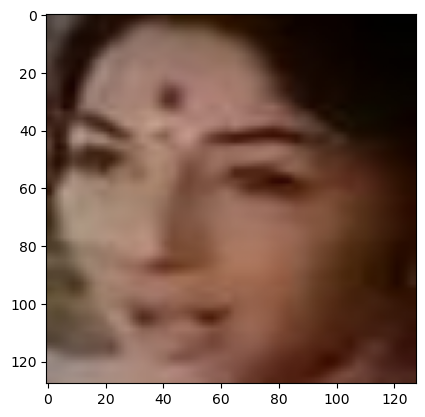

In [7]:
# show an example
plt.imshow(train_images[10])

In [8]:
# check the shape of your images
train_images.shape

(19906, 128, 128, 3)

In [9]:
# check the shape of your labels and ensure the data looks correct (should be all 0-2)
train_labels

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], shape=(19906, 3))

In [10]:
# build the model
model = keras.Sequential(
    [
        keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(128, 128, 3)),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(128, (3, 3), activation='relu'),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(264, (3, 3), activation='relu'),
        keras.layers.MaxPooling2D(),
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(3, activation='softmax'),
    ]
)

# compile the model 
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# train the model
model.fit(train_images, train_labels, batch_size=64, epochs=20)

c:\Users\budde\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 281s 893ms/step - accuracy: 0.5810 - loss: 0.9451
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 280s 898ms/step - accuracy: 0.6753 - loss: 0.7425
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 281s 900ms/step - accuracy: 0.6938 - loss: 0.7059
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 282s 904ms/step - accuracy: 0.7512 - loss: 0.5951
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 281s 901ms/step - accuracy: 0.7797 - loss: 0.5296
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 286s 917ms/step - accuracy: 0.8296 - loss: 0.4168
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 282s 905ms/step - accuracy: 0.8870 - loss: 0.2995
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 285s 913ms/step - accuracy: 0.9181 - loss: 0.2135
Epoch 9/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 284s 910ms/step - accuracy: 0.9512 - loss: 0.1339
Epoch 10/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 285s 912ms/step - accuracy: 0.9701 - loss: 0.0848
Epoch 11/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 298s 957ms/step - accuracy: 0.9805 - loss: 0.0617
Epoch 12

In [11]:
# save the model for future use
model.save('age_classifier_model.h5')

In [12]:
# create a function to easily test/use our model on specific images
def predict_age_from_image(image_path, model):
    # load and preprocess the image
    image = cv2.imread(image_path)
    
    if image is None:
        return "Error: Could not load image. Please check the file path."
    
    # convert BGR to RGB (OpenCV loads in BGR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # resize to match training dimensions
    image = cv2.resize(image, (128, 128))
    
    # normalize pixel values
    image = image / 255.0
    
    # add batch dimension
    image = np.expand_dims(image, axis=0)
    
    # make prediction
    predictions = model.predict(image)
    
    # get the predicted class
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100
    
    # map class to age group
    age_groups = {0: 'YOUNG', 1: 'MIDDLE', 2: 'OLD'}
    predicted_age = age_groups[predicted_class]
    
    # display the image with prediction
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.imread(image_path))
    plt.axis('off')
    plt.title(f'Predicted Age Group: {predicted_age}\nConfidence: {confidence:.2f}%', 
              fontsize=14, fontweight='bold')
    plt.show()
    
    # print detailed results
    print(f"\nPrediction Results:")
    print(f"=" * 40)
    print(f"Predicted Age Group: {predicted_age}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"\nAll Class Probabilities:")
    for i, prob in enumerate(predictions[0]):
        print(f"  {age_groups[i]}: {prob*100:.2f}%")
    
    return predicted_age, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


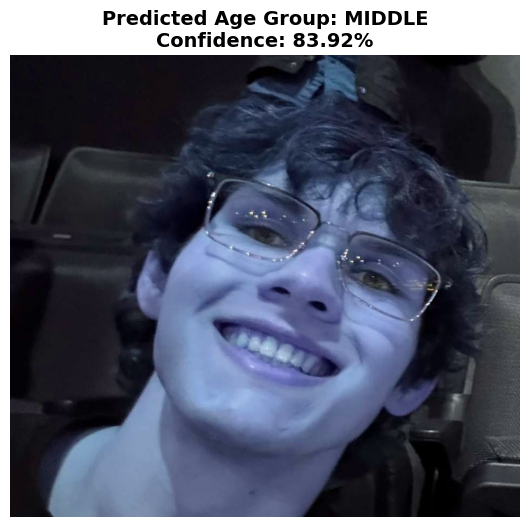


Prediction Results:
Predicted Age Group: MIDDLE
Confidence: 83.92%

All Class Probabilities:
  YOUNG: 0.01%
  MIDDLE: 83.92%
  OLD: 16.07%


In [14]:
predicted, confidence = predict_age_from_image("C:\\Users\\budde\\Desktop\\DS5110\\Age-Recognition\\myface1.jpg", model)